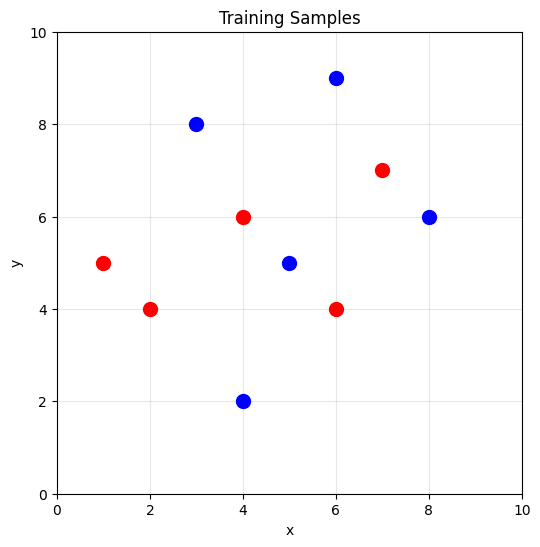

input_cls.shape[1] 10
Number of training samples: N = 10
Hidden units: H = 80
Output units: K = 2
Learning rate (Adam): eta = 0.01
Step 100/3000, Error = 0.451785
Step 200/3000, Error = 0.451935
Step 300/3000, Error = 0.451022
Step 400/3000, Error = 0.444078
Step 500/3000, Error = 0.422467
Step 600/3000, Error = 0.385860
Step 700/3000, Error = 0.330286
Step 800/3000, Error = 0.275562
Step 900/3000, Error = 0.249510
Step 1000/3000, Error = 0.235443
Step 1100/3000, Error = 0.211737
Step 1200/3000, Error = 0.175221
Step 1300/3000, Error = 0.131475
Step 1400/3000, Error = 0.087022
Step 1500/3000, Error = 0.054039
Step 1600/3000, Error = 0.034612
Step 1700/3000, Error = 0.023667
Step 1800/3000, Error = 0.016736
Step 1900/3000, Error = 0.012193
Step 2000/3000, Error = 0.009519
Step 2100/3000, Error = 0.007722
Step 2200/3000, Error = 0.006416
Step 2300/3000, Error = 0.005425
Step 2400/3000, Error = 0.004649
Step 2500/3000, Error = 0.004029
Step 2600/3000, Error = 0.003523
Step 2700/3000, Erro

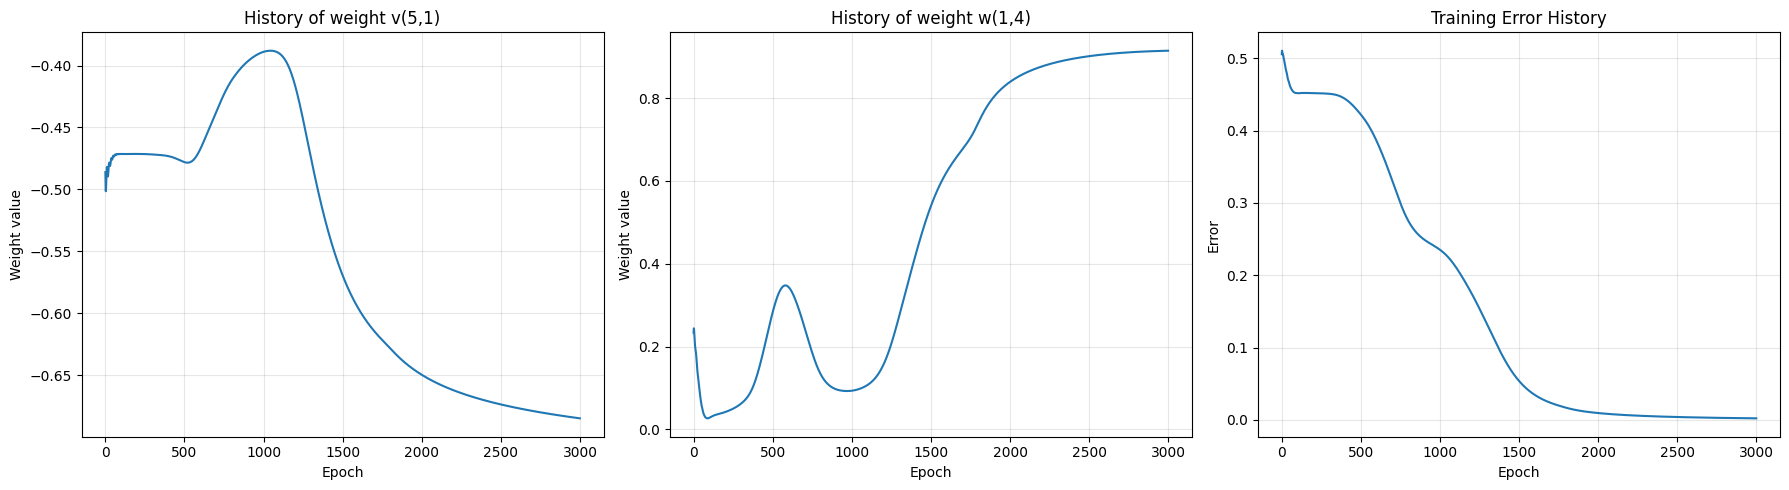

NameError: name 'model' is not defined

<Figure size 800x800 with 0 Axes>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(7)

# ── Normalization helpers ─────────────────────────────────────────────────────
def mapminmax_apply(data, ymin=0, ymax=1):
    dmin = data.min(axis=1, keepdims=True)
    dmax = data.max(axis=1, keepdims=True)
    data_n = (ymax - ymin) * (data - dmin) / (dmax - dmin) + ymin
    params = {'dmin': dmin, 'dmax': dmax, 'ymin': ymin, 'ymax': ymax}
    return data_n, params

def mapminmax_apply_with_params(data, params):
    return (params['ymax'] - params['ymin']) * (data - params['dmin']) / (params['dmax'] - params['dmin']) + params['ymin']

# ── Training data ─────────────────────────────────────────────────────────────
input_cls = np.array([[1, 2, 7, 4, 6, 6, 4, 8, 5, 3],
                      [5, 4, 7, 6, 4, 9, 2, 6, 5, 8]], dtype=float)
red_or_blue_cls = np.array([[0, 0, 0, 0, 0, 1, 1, 1, 1, 1],
                             [1, 1, 1, 1, 1, 0, 0, 0, 0, 0]], dtype=float)

plt.figure(figsize=(6, 6))
for i in range(input_cls.shape[1]):
    if red_or_blue_cls[0, i] > red_or_blue_cls[1, i]:
        plt.plot(input_cls[0, i], input_cls[1, i], 'bo', markersize=10)
    else:
        plt.plot(input_cls[0, i], input_cls[1, i], 'ro', markersize=10)
plt.xlabel('x'); plt.ylabel('y'); plt.title('Training Samples')
plt.xlim(0, 10); plt.ylim(0, 10); plt.grid(True, alpha=0.3); plt.show()

# ── Normalize ─────────────────────────────────────────────────────────────────
input_cls_normalized, ps_cls = mapminmax_apply(input_cls, 0, 1)
number_training_samples_cls = input_cls.shape[1]
print("input_cls.shape[1]", input_cls.shape[1])
print(f"Number of training samples: N = {number_training_samples_cls}")

# ── Initialization ────────────────────────────────────────────────────────────
num_hidden_nodes = 80
num_output_nodes = 2
num_input_nodes  = 2

# Weights + biases (1 hidden layer)
weights_hidden1          = np.random.uniform(-0.5, 0.5, (num_input_nodes,  num_hidden_nodes))
weights_hidden_to_output = np.random.uniform(-0.5, 0.5, (num_hidden_nodes, num_output_nodes))
bias_hidden1             = np.zeros((num_hidden_nodes, 1))
bias_output              = np.zeros((num_output_nodes, 1))

# Adam optimizer state
learning_rate = 0.01
beta1, beta2, eps = 0.9, 0.999, 1e-8
mW1  = np.zeros_like(weights_hidden1);          vW1  = np.zeros_like(weights_hidden1)
mb1  = np.zeros_like(bias_hidden1);             vb1  = np.zeros_like(bias_hidden1)
mWo  = np.zeros_like(weights_hidden_to_output); vWo  = np.zeros_like(weights_hidden_to_output)
mbo  = np.zeros_like(bias_output);              vbo  = np.zeros_like(bias_output)

def adam_update(w, g, m, v, t):
    m = beta1 * m + (1 - beta1) * g
    v = beta2 * v + (1 - beta2) * g ** 2
    mh = m / (1 - beta1 ** t)
    vh = v / (1 - beta2 ** t)
    return w + learning_rate * mh / (np.sqrt(vh) + eps), m, v

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -20, 20)))

print(f"Hidden units: H = {num_hidden_nodes}")
print(f"Output units: K = {num_output_nodes}")
print(f"Learning rate (Adam): eta = {learning_rate}")

# ── Training ──────────────────────────────────────────────────────────────────
epochs    = 3000
adam_step = 0
v_history_cls   = []
w_history_cls   = []
err_history_cls = []

for j in range(1, epochs + 1):
    err_cls = 0

    # Accumulate gradients over all samples (batch gradient descent)
    grad_W1  = np.zeros_like(weights_hidden1)
    grad_b1  = np.zeros_like(bias_hidden1)
    grad_Wo  = np.zeros_like(weights_hidden_to_output)
    grad_bo  = np.zeros_like(bias_output)

    for c in range(number_training_samples_cls):
        value_input = input_cls_normalized[:, c:c+1]
        r_cls       = red_or_blue_cls[:, c:c+1]

        # Forward pass hidden layer (sigmoid)
        z1            = weights_hidden1.T @ value_input + bias_hidden1
        value_hidden1 = sigmoid(z1)

        # Forward pass output layer (softmax)
        z_out   = weights_hidden_to_output.T @ value_hidden1 + bias_output
        exp_z   = np.exp(z_out - z_out.max())
        value_output = exp_z / exp_z.sum()

        err_cls += np.abs(r_cls - value_output).sum()

        # Backward pass
        delta_out = r_cls - value_output                                          # K x 1
        grad_Wo  += value_hidden1 @ delta_out.T                                  # H x K
        grad_bo  += delta_out                                                     # K x 1

        delta_h   = (weights_hidden_to_output @ delta_out) * value_hidden1 * (1 - value_hidden1)  # H x 1
        grad_W1  += value_input @ delta_h.T                                      # I x H
        grad_b1  += delta_h                                                       # H x 1

    # Adam weight update (average gradients over batch)
    adam_step += 1
    weights_hidden1,          mW1, vW1 = adam_update(weights_hidden1,          grad_W1 / number_training_samples_cls, mW1, vW1, adam_step)
    bias_hidden1,             mb1, vb1 = adam_update(bias_hidden1,             grad_b1 / number_training_samples_cls, mb1, vb1, adam_step)
    weights_hidden_to_output, mWo, vWo = adam_update(weights_hidden_to_output, grad_Wo / number_training_samples_cls, mWo, vWo, adam_step)
    bias_output,              mbo, vbo = adam_update(bias_output,              grad_bo / number_training_samples_cls, mbo, vbo, adam_step)

    w_history_cls.append(weights_hidden1[0, min(3, num_hidden_nodes-1)])
    v_history_cls.append(weights_hidden_to_output[min(4, num_hidden_nodes-1), 0])

    err_history_cls.append(err_cls / (number_training_samples_cls * 2.0))
    if j % 100 == 0:
        print(f"Step {j}/{epochs}, Error = {err_history_cls[-1]:.6f}")

print(f"\nTraining complete. Final error = {err_history_cls[-1]:.6f}")

# ── Training history plots ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(v_history_cls);    axes[0].set_title('History of weight v(5,1)');  axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Weight value'); axes[0].grid(True, alpha=0.3)
axes[1].plot(w_history_cls);    axes[1].set_title('History of weight w(1,4)');  axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Weight value'); axes[1].grid(True, alpha=0.3)
axes[2].plot(err_history_cls);  axes[2].set_title('Training Error History');    axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Error');        axes[2].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


s


# ── Test / decision boundary plot ─────────────────────────────────────────────
plt.figure(figsize=(8, 8))

for x_test in np.arange(0, 10.1, 0.1):
    for y_test in np.arange(0, 10.1, 0.1):
        test_input = np.array([[x_test], [y_test]])
        X_n_t = mapminmax_apply_with_params(test_input, ps_cls)

        Z1    = sigmoid(weights_hidden1.T @ X_n_t + bias_hidden1)
        Y_raw = weights_hidden_to_output.T @ Z1 + bias_output
        exp_y = np.exp(Y_raw - Y_raw.max())
        Y_t   = exp_y / exp_y.sum()

        if Y_t[0, 0] >= Y_t[1, 0]:
            plt.plot(x_test, y_test, 'b.', markersize=1)
        else:
            plt.plot(x_test, y_test, 'r.', markersize=1)

for i in range(number_training_samples_cls):
    x_pt = input_cls[0, i]; y_pt = input_cls[1, i]
    if red_or_blue_cls[0, i] > red_or_blue_cls[1, i]:
        plt.plot(x_pt, y_pt, 'bo', markersize=12, markeredgecolor='black', markeredgewidth=2)
    else:
        plt.plot(x_pt, y_pt, 'ro', markersize=12, markeredgecolor='black', markeredgewidth=2)

plt.xlabel('x'); plt.ylabel('y'); plt.title('Classification Result: Decision Regions')
plt.xlim(0, 10); plt.ylim(0, 10); plt.grid(True, alpha=0.3); plt.show()
